# Generating Points on the Flag Manifold

## Setup

In [1]:
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)
icdf_normal = torch.distributions.Normal(loc=torch.zeros(1,device=DEVICE),scale=torch.ones(1,device=DEVICE)).icdf

MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12
torch device = cpu


## Transform and Generators

In [18]:
def tff_qr(u, lam):
    t = lam.size(-1)
    assert u.size(-1)==(t**2)
    assert (0<=u).all()
    assert (u<=1).all()
    u = u.reshape((*u.shape[:-1],t,t))
    v = icdf_normal(u)
    q,r = torch.linalg.qr(v)
    d = torch.diagonal(r,dim1=-2,dim2=-1).sign()
    q = q*d[...,None,:]
    assert torch.allclose(torch.einsum("...ij,...jk->...ik",q,r*d[...,:,None]),v)
    f = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    return f
def tff_eig(u, lam):
    t = lam.size(-1) 
    assert u.size(-1)==(t*(t+1)//2+t)
    alpha = icdf_normal(u[...,:t])
    beta = icdf_normal(u[...,t:(-t)])/np.sqrt(2)
    signs = torch.where(u[...,(-t):]>1/2,1.,-1.).to(DEVICE)
    il0,il1 = torch.tril_indices(t,t,offset=-1,device=DEVICE)
    v = torch.eye(t,device=DEVICE)*alpha[...,None]
    v[...,il0,il1] = beta
    v += v.tril(-1).transpose(dim0=-2,dim1=-1)
    assert torch.allclose(v[...,torch.arange(t,device=DEVICE),torch.arange(t,device=DEVICE)],alpha)
    gamma,q = torch.linalg.eigh(v)
    q = q*signs[...,None,:] # this is required because torch.eigh pins the sign to make the largest entry of each eigenvector positive
    assert torch.allclose(torch.einsum("...ij,...kj->...ik",q,q),torch.eye(t))
    assert torch.allclose(torch.einsum("...ij,...j,...kj->...ik",q,gamma,q),v)
    f = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    return f
def genf_qr_iid_x_equal_w(n, lam, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.rand((n,t**2),generator=rng,device=DEVICE)
    x = tff_qr(u,lam)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_qr_ld_x_equal_w(n, lam, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    x = tff_qr(u,lam)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_eig_iid_x_equal_w(n, lam, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.rand((n,t*(t+1)//2+t),generator=rng,device=DEVICE)
    x = tff_eig(u,lam)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_eig_ld_x_equal_w(n, lam, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t*(t+1)//2+t,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    x = tff_eig(u,lam)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
# genf_qr_iid_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE));
# genf_qr_ld_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE));
# genf_eig_iid_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE));
# genf_eig_ld_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE));

In [19]:
def theoretical_1_moments_real_orthogonal(lam):
    t = lam.size(-1)
    return lam.sum(-1)/t*torch.eye(t,device=DEVICE)
def theoretical_2_moments_real_orthogonal(lam):
    t = lam.size(-1)
    T1 = torch.sum(lam)**2
    T2 = torch.sum(lam**2)
    denom = t*(t-1)*(t+2)
    alpha = ((t+1)*T1-2*T2)/denom
    beta = (t*T2-T1)/denom
    eye_vec = torch.eye(t,device=DEVICE).flatten()
    M1 = eye_vec[...,:,None]*eye_vec[...,None,:]
    M2 = torch.eye(t**2,device=DEVICE)
    W = torch.zeros((t**2,t**2),device=DEVICE)
    for i in range(t):
        for j in range(t):
            W[i*t+j,j*t+i] = 1
    return alpha*M1+beta*(M2+W)
lam = torch.arange(1,5,device=DEVICE) 
x,w = genf_eig_iid_x_equal_w(2**20,lam=lam)
E1hat = (w[...,:,None,None]*x).sum(-3)
xf = x.flatten(start_dim=-2)
E2hat = (w[...,:,None,None]*xf[...,:,None]*xf[...,None,:]).sum(-3)
print()
E1 = theoretical_1_moments_real_orthogonal(lam)
E2 = theoretical_2_moments_real_orthogonal(lam)
with np.printoptions(formatter={"float":lambda x: "%.1e"%x},linewidth=np.inf):
    print("E1")
    print(E1.numpy())
    print("E1hat")
    print(E1hat.numpy())
    print()
    print("E2")
    print(E2.numpy())
    print("E2hat")
    print(E2hat.numpy())
assert torch.allclose(E1,E1hat,atol=1e-2)
assert torch.allclose(E2,E2hat,atol=1e-2)


E1
[[2.5e+00 0.0e+00 0.0e+00 0.0e+00]
 [0.0e+00 2.5e+00 0.0e+00 0.0e+00]
 [0.0e+00 0.0e+00 2.5e+00 0.0e+00]
 [0.0e+00 0.0e+00 0.0e+00 2.5e+00]]
E1hat
[[2.5e+00 7.8e-05 1.9e-04 4.6e-04]
 [7.8e-05 2.5e+00 7.9e-04 1.4e-03]
 [1.9e-04 7.9e-04 2.5e+00 7.1e-04]
 [4.6e-04 1.4e-03 7.1e-04 2.5e+00]]

E2
[[6.7e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 6.1e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 6.1e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 6.1e+00]
 [0.0e+00 2.8e-01 0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00]
 [0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00]
 [0.0e+00 0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00]
 [0.0e+00 2.8e-01 0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00]
 [6.1e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 6.7e+00

In [25]:
def get_q(u, left=False):
    t = int((np.sqrt(1+8*u.size(-1))-1)/2)
    il0,il1 = torch.tril_indices(t,t,device=DEVICE)
    eyet = torch.eye(t,device=DEVICE)
    q = torch.zeros((*u.shape[:-1],t,t),device=DEVICE)+eyet 
    k = 0
    zeros = torch.zeros((*u.shape[:-1],t),device=DEVICE)
    irange = torch.arange(t,device=DEVICE)
    for i in range(t):
        if left:
            v = zeros.index_add(-1,irange[:(i+1)],u[...,k:(k+i+1)])
            k += i+1
        else:
            v = zeros.index_add(-1,irange[i:],u[...,k:(k+t-i)])
            k += t-i
        tau = 2/torch.sum(v**2,dim=-1)
        tau = torch.where(torch.isinf(tau),torch.zeros_like(tau),tau)
        vTQ = torch.einsum("...i,...ij->...j",v,q)
        q = q-tau[...,None,None]*torch.einsum("...i,...j->...ij",v,vTQ)
    # assert torch.allclose(torch.einsum("...ji,...jk->...ik",q,q),eyet)
    # assert torch.allclose(torch.einsum("...ij,...kj->...ik",q,q),eyet)
    return q
# get_q(torch.rand(3,5,4*(4+1)//2,device=DEVICE));

In [27]:
def genf_opt1_x_w(n, lam, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    wu0 = torch.cat([
        torch.ones((n,1),device=DEVICE)/n,
        torch.from_numpy(qp.DigitalNetB2(t*(t+1)//2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)],dim=-1)
    E1 = theoretical_1_moments_real_orthogonal(lam)
    def loss(wu):
        w = wu[...,0]
        u = wu[...,1:]
        q = get_q(u)
        x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
        xsum = torch.einsum("...i,...ijk->...jk",w,x)
        return xsum,x,w
    wu,x,w = agsutil.lm_opt(
        f = loss, 
        theta0 = wu0, 
        ytrue = E1,
        iters = 100,
        verbose = verbose,
        jacfwd = False,
    )
    return x,w
x,w = genf_opt1_x_w(n=128,lam=torch.arange(1,6,dtype=float,device=DEVICE),verbose=1,seed=7)

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 1.3e+00   | 1.3e+00   | 1.3e+00   | 1.3e+00   | 1.3e+00   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.0        
    1          | 4.7e-06   | 4.7e-06   | 4.7e-06   | 4.7e-06   | 4.7e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+0

In [38]:
def genf_opt2_x_w(n, lam, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    wu0 = torch.cat([
        torch.ones((n,1),device=DEVICE)/n,
        torch.from_numpy(qp.DigitalNetB2(t*(t+1)//2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)],dim=-1)
    E2 = theoretical_2_moments_real_orthogonal(lam)
    def loss(wu):
        w = wu[...,0]
        u = wu[...,1:]
        q = get_q(u)
        x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
        xf = x.flatten(start_dim=-2)
        xsum = torch.einsum("...ij,...ik,...i->...jk",xf,xf,w)
        return xsum,x,w
    wu,x,w = agsutil.lm_opt(
        f = loss, 
        theta0 = wu0, 
        ytrue = E2,
        iters = 100,
        verbose = verbose,
        jacfwd = False,
    )
    # print(data['losses_quantiles']['50'])
    return x,w
x,w = genf_opt2_x_w(n=128,lam=torch.arange(1,6,dtype=float,device=DEVICE),verbose=1,seed=11)

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 1.2e+02   | 1.2e+02   | 1.2e+02   | 1.2e+02   | 1.2e+02   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.1        
    1          | 1.1e+01   | 1.1e+01   | 1.1e+01   | 1.1e+01   | 1.1e+01   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+0

In [39]:
def ffunc1(x):
    n = x.size(-1)
    assert x.shape[-2:]==(n,n)
    nrange = torch.arange(n,device=DEVICE)
    xnorm = torch.linalg.matrix_norm(x,ord=-torch.inf)
    return xnorm
def get_approx(ffunc, genf, n, lam, seed=None, verbose=None):
    x,w = genf(n=n,lam=lam,seed=seed,verbose=verbose)
    y = ffunc(x)
    muhat = (w*y).sum()
    return muhat 
d = 5
lam = torch.arange(1,d+1,device=DEVICE,dtype=float)
muref = get_approx(ffunc1,genf_qr_ld_x_equal_w,n=2**21,lam=lam,seed=None,verbose=False)
n = 2**torch.arange(2,8)
print("muref = %.4e"%muref)
genf_funcs = [
    [r"QR IID $x$ equal $w$", genf_qr_iid_x_equal_w],
    [r"QR LD $x$ equal $w$", genf_qr_ld_x_equal_w],
    [r"Eig IID $x$ equal $w$", genf_eig_iid_x_equal_w],
    [r"Eig LD $x$ equal $w$", genf_eig_ld_x_equal_w],
    [r"Opt1 $x$ and $w$", genf_opt1_x_w],
    [r"Opt2 $x$ and $w$", genf_opt2_x_w],
    ]
trials = 5
seeds = [i for i in range(trials)]
errors = torch.empty((len(genf_funcs),len(n),trials))
t0 = time.perf_counter()
for i,(key,genf) in enumerate(genf_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        for t in range(trials):
            muhat = get_approx(ffunc1,genf,n=n[j],lam=lam,seed=seeds[t],verbose=False)
            errors[i,j,t] = float(torch.abs(muhat-muref).cpu())
            print("        trial %-10d time %-10.1f muhat %-10.1e error %-10.1e"%(t,time.perf_counter()-t0,muhat,errors[i,j,t]))

muref = 3.7043e+00
QR IID $x$ equal $w$
    n = 4
        trial 0          time 0.0        muhat 4.0e+00    error 2.9e-01   
        trial 1          time 0.0        muhat 3.3e+00    error 4.1e-01   
        trial 2          time 0.0        muhat 4.2e+00    error 5.1e-01   
        trial 3          time 0.0        muhat 3.6e+00    error 8.4e-02   
        trial 4          time 0.0        muhat 3.5e+00    error 2.4e-01   
    n = 8
        trial 0          time 0.0        muhat 3.7e+00    error 3.4e-02   
        trial 1          time 0.0        muhat 3.6e+00    error 1.3e-01   
        trial 2          time 0.0        muhat 3.8e+00    error 1.2e-01   
        trial 3          time 0.0        muhat 3.5e+00    error 1.8e-01   
        trial 4          time 0.0        muhat 3.7e+00    error 5.1e-02   
    n = 16
        trial 0          time 0.0        muhat 3.8e+00    error 7.4e-02   
        trial 1          time 0.0        muhat 3.8e+00    error 1.4e-01   
        trial 2          time

/Users/alegresor/Desktop/agsutil/agsutil/algos.py:399: UserWarning: 
        For T the number of inputs and K the number of outputs:
            torch.func.jacfwd performs best when T << K. 
            torch.func.jacrev performs best when K << T.
        You are using torch.func.jacrev but T = 64 < 625 = K. 
        Try using torch.func.jacrev by setting jacfwd = True.
  if warn and (not jacfwd) and T<K: warnings.warn('''


        trial 0          time 5.1        muhat 3.5e+00    error 2.1e-01   
        trial 1          time 6.3        muhat 2.5e+00    error 1.2e+00   
        trial 2          time 7.5        muhat 2.8e+00    error 8.8e-01   
        trial 3          time 8.6        muhat 3.5e+00    error 1.6e-01   
        trial 4          time 9.8        muhat 2.8e+00    error 8.6e-01   
    n = 8


/Users/alegresor/Desktop/agsutil/agsutil/algos.py:399: UserWarning: 
        For T the number of inputs and K the number of outputs:
            torch.func.jacfwd performs best when T << K. 
            torch.func.jacrev performs best when K << T.
        You are using torch.func.jacrev but T = 128 < 625 = K. 
        Try using torch.func.jacrev by setting jacfwd = True.
  if warn and (not jacfwd) and T<K: warnings.warn('''


        trial 0          time 11.4       muhat 3.6e+00    error 1.3e-01   
        trial 1          time 13.0       muhat 2.9e+00    error 7.6e-01   
        trial 2          time 14.6       muhat 3.1e+00    error 6.3e-01   
        trial 3          time 16.1       muhat 3.6e+00    error 1.4e-01   
        trial 4          time 17.7       muhat 3.4e+00    error 3.0e-01   
    n = 16


/Users/alegresor/Desktop/agsutil/agsutil/algos.py:399: UserWarning: 
        For T the number of inputs and K the number of outputs:
            torch.func.jacfwd performs best when T << K. 
            torch.func.jacrev performs best when K << T.
        You are using torch.func.jacrev but T = 256 < 625 = K. 
        Try using torch.func.jacrev by setting jacfwd = True.
  if warn and (not jacfwd) and T<K: warnings.warn('''


        trial 0          time 20.2       muhat 3.5e+00    error 2.2e-01   
        trial 1          time 22.7       muhat 3.0e+00    error 6.6e-01   
        trial 2          time 25.2       muhat 3.2e+00    error 5.4e-01   
        trial 3          time 27.8       muhat 3.3e+00    error 3.7e-01   
        trial 4          time 30.4       muhat 3.3e+00    error 4.3e-01   
    n = 32


/Users/alegresor/Desktop/agsutil/agsutil/algos.py:399: UserWarning: 
        For T the number of inputs and K the number of outputs:
            torch.func.jacfwd performs best when T << K. 
            torch.func.jacrev performs best when K << T.
        You are using torch.func.jacrev but T = 512 < 625 = K. 
        Try using torch.func.jacrev by setting jacfwd = True.
  if warn and (not jacfwd) and T<K: warnings.warn('''


        trial 0          time 30.8       muhat 3.7e+00    error 1.9e-02   
        trial 1          time 31.3       muhat 3.4e+00    error 3.1e-01   
        trial 2          time 31.8       muhat 3.8e+00    error 4.9e-02   
        trial 3          time 32.2       muhat 3.8e+00    error 8.8e-02   
        trial 4          time 32.7       muhat 3.8e+00    error 1.1e-01   
    n = 64
        trial 0          time 33.5       muhat 3.7e+00    error 4.6e-02   
        trial 1          time 34.4       muhat 3.6e+00    error 1.1e-01   
        trial 2          time 35.3       muhat 3.7e+00    error 2.0e-02   
        trial 3          time 36.2       muhat 3.7e+00    error 5.6e-03   
        trial 4          time 37.1       muhat 3.6e+00    error 1.5e-01   
    n = 128
        trial 0          time 39.2       muhat 3.6e+00    error 7.6e-02   
        trial 1          time 41.0       muhat 3.9e+00    error 1.5e-01   
        trial 2          time 42.9       muhat 3.6e+00    error 7.4e-02   
  

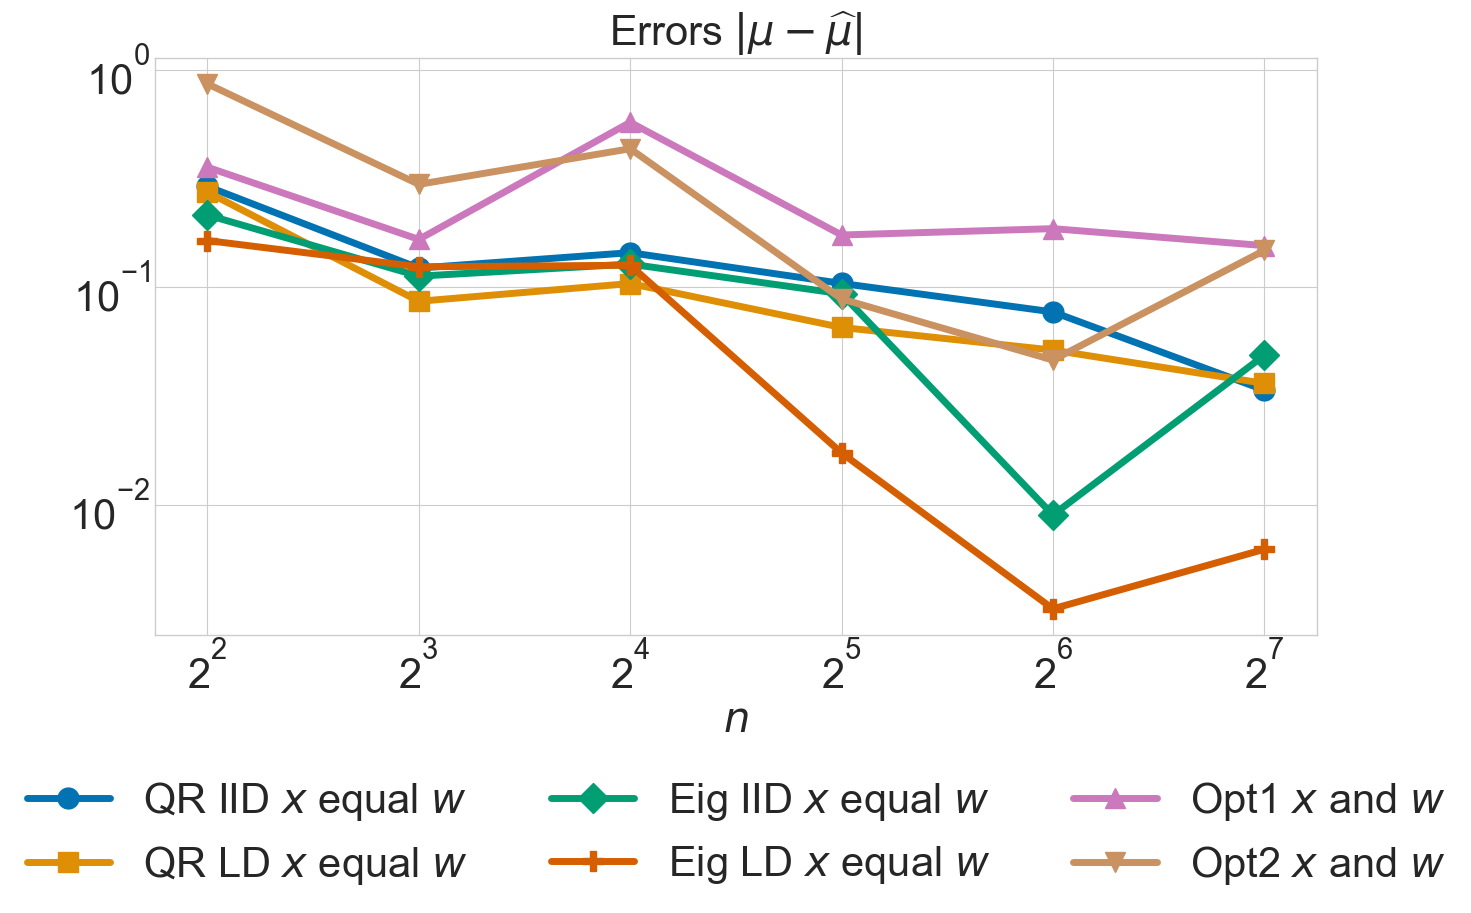

In [40]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(MPLP["PW"]/2,MPLP["PW"]/4),sharex=True,sharey=False)
for i,(key,sphere_func) in enumerate(genf_funcs):
    ax.plot(n,errors[i].median(-1).values,color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key)
ax.legend(frameon=False,ncols=3,loc="lower center",bbox_to_anchor=(.5,-.5))
ax.set_title(r"Errors $|\mu - \widehat{\mu}|$")
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=2)
ax.set_xlabel(r"$n$");

In [41]:
errors_df = pd.DataFrame(errors.median(-1).values.T,columns=[name for (name,func) in genf_funcs])
errors_df['n'] = n
errors_df.set_index('n')
errors_df

,QR IID $x$ equal $w$,QR LD $x$ equal $w$,Eig IID $x$ equal $w$,Eig LD $x$ equal $w$,Opt1 $x$ and $w$,Opt2 $x$ and $w$,n
0,0.290529,0.273653,0.214689,0.163905,0.356084,0.860512,4
1,0.122501,0.086222,0.112476,0.124163,0.165945,0.297126,8
2,0.144208,0.104017,0.127794,0.126226,0.572422,0.433063,16
3,0.104158,0.065377,0.093324,0.017327,0.173822,0.088387,32
4,0.077022,0.051438,0.008988,0.003329,0.185932,0.046302,64
5,0.033680,0.036170,0.048685,0.006250,0.155356,0.147591,128
